# Analisis Perbandingan Berbagai Algoritma Regresi dalam Estimasi Harga Jual Laptop Berdasarkan Spesifikasi Hardware

**Disusun Oleh:**
* Nama : Muhammad Aril Andrian
* NIM  : F1G123024
* Program Studi : Ilmu Komputer, Universitas Halu Oleo

---
**Tujuan Proyek:**
Proyek Machine Learning ini bertujuan untuk membangun dan membandingkan kinerja dari beberapa algoritma regresi dalam memprediksi harga jual laptop berdasarkan spesifikasi komponen hardware-nya. Evaluasi model difokuskan pada tingkat akurasi prediksi (R² Score) dan tingkat kesalahan (MAE, RMSE).

In [1]:
# ==========================================
# CELL 1: IMPORT LIBRARY DASAR
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re # Library untuk membersihkan teks
import warnings

# Mengatur gaya grafik dan mengabaikan peringatan
sns.set_theme(style="whitegrid")
warnings.filterwarnings('ignore')

In [2]:
# ==========================================
# CELL 2: LOAD DATASET & INFO DASAR
# ==========================================
# Memuat dataset (Pastikan file berada di folder yang sama)
df = pd.read_csv('laptop_data_cleaned.csv')

print("--- 5 Baris Pertama Dataset ---")
display(df.head())

print("\n--- Informasi Dataset ---")
df.info()

--- 5 Baris Pertama Dataset ---


,Company,TypeName,Ram,Weight,Price,TouchScreen,Ips,Ppi,Cpu_brand,HDD,SSD,Gpu_brand,Os
0,Apple,Ultrabook,8,1.37,11.175755,0,1,226.983005,Intel Core i5,0,128,Intel,Mac
1,Apple,Ultrabook,8,1.34,10.776777,0,0,127.677940,Intel Core i5,0,0,Intel,Mac
2,HP,Notebook,8,1.86,10.329931,0,0,141.211998,Intel Core i5,0,256,Intel,Others
3,Apple,Ultrabook,16,1.83,11.814476,0,1,220.534624,Intel Core i7,0,512,AMD,Mac
4,Apple,Ultrabook,8,1.37,11.473101,0,1,226.983005,Intel Core i5,0,256,Intel,Mac



--- Informasi Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1273 entries, 0 to 1272
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Company      1273 non-null   object 
 1   TypeName     1273 non-null   object 
 2   Ram          1273 non-null   int64  
 3   Weight       1273 non-null   float64
 4   Price        1273 non-null   float64
 5   TouchScreen  1273 non-null   int64  
 6   Ips          1273 non-null   int64  
 7   Ppi          1273 non-null   float64
 8   Cpu_brand    1273 non-null   object 
 9   HDD          1273 non-null   int64  
 10  SSD          1273 non-null   int64  
 11  Gpu_brand    1273 non-null   object 
 12  Os           1273 non-null   object 
dtypes: float64(3), int64(5), object(5)
memory usage: 129.4+ KB


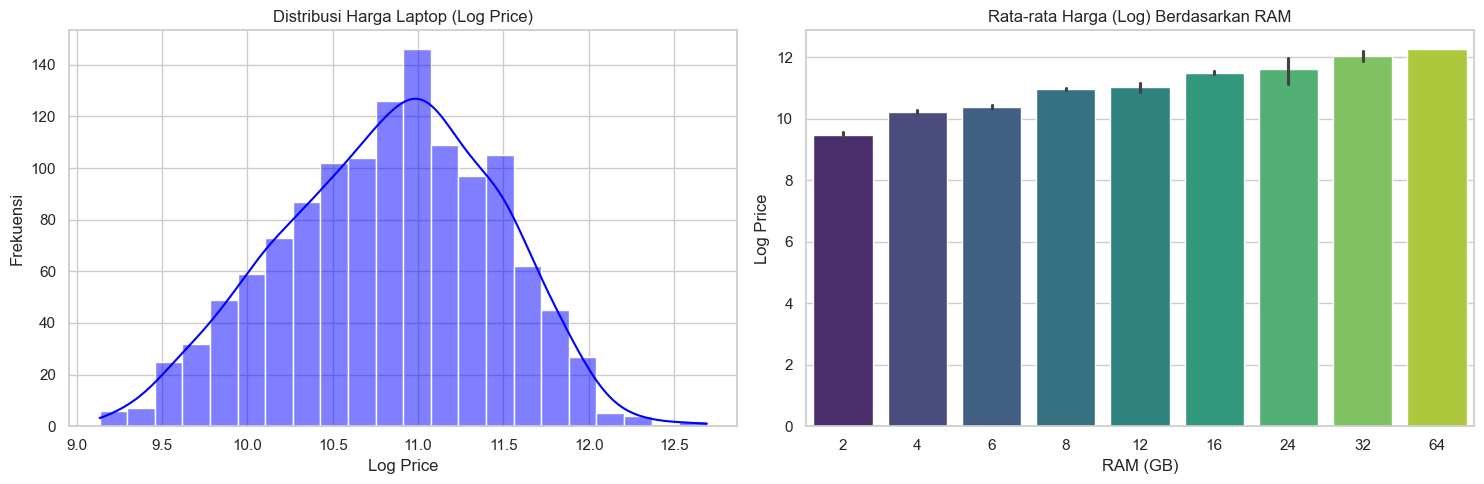

In [3]:
# ==========================================
# CELL 3: VISUALISASI DATA
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Grafik 1: Distribusi Harga (Log Price)
sns.histplot(df['Price'], kde=True, color='blue', ax=axes[0])
axes[0].set_title('Distribusi Harga Laptop (Log Price)')
axes[0].set_xlabel('Log Price')
axes[0].set_ylabel('Frekuensi')

# Grafik 2: Pengaruh RAM terhadap Harga
sns.barplot(x=df['Ram'], y=df['Price'], palette='viridis', ax=axes[1])
axes[1].set_title('Rata-rata Harga (Log) Berdasarkan RAM')
axes[1].set_xlabel('RAM (GB)')
axes[1].set_ylabel('Log Price')

plt.tight_layout()
plt.show()

--- ANALISIS KORELASI ANTAR VARIABEL NUMERIK ---


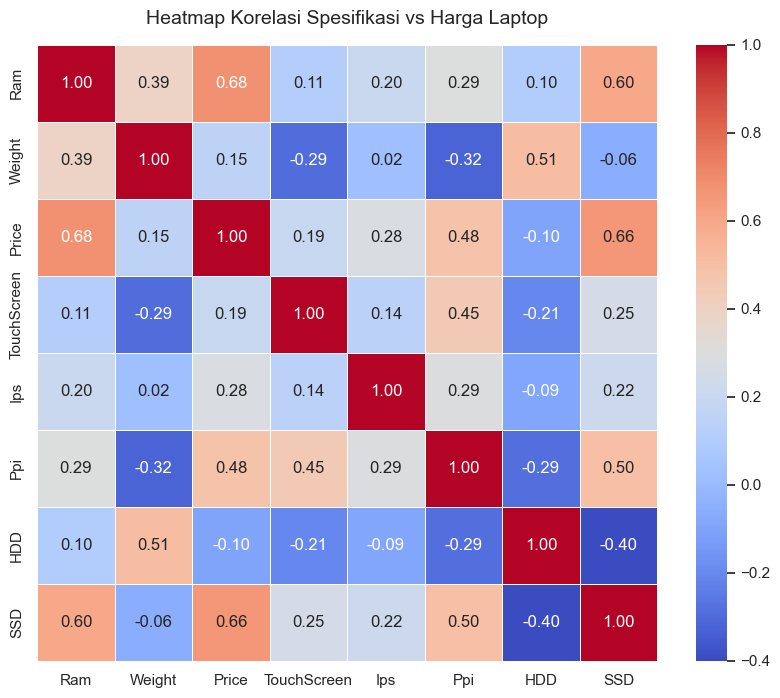


--- INSIGHT PENTING DARI DATASET ---
1. Korelasi Terkuat: Berdasarkan heatmap, RAM memiliki korelasi positif paling kuat terhadap Harga (Price). Semakin besar RAM, harga laptop melonjak signifikan.
2. Pengaruh Layar: Kualitas layar (PPI/Pixels Per Inch) juga memiliki korelasi yang sangat kuat dengan harga, menandakan layar tajam adalah indikator laptop premium.
3. SSD vs HDD: Penggunaan SSD memiliki korelasi positif dengan harga, sedangkan HDD berkorelasi negatif. Ini menunjukkan laptop mahal modern sudah meninggalkan HDD.
4. Berat (Weight): Berat laptop memiliki korelasi yang sangat kecil (mendekati 0) terhadap harga, artinya pembeli lebih mementingkan performa mesin (RAM/SSD) daripada seberapa ringan laptop tersebut.


In [4]:
# ==========================================
# CELL 3B: EDA MENDALAM (KORELASI & INSIGHT)
# ==========================================
import seaborn as sns
import matplotlib.pyplot as plt

print("--- ANALISIS KORELASI ANTAR VARIABEL NUMERIK ---")

# Memilih hanya kolom yang berisi angka untuk analisis korelasi
kolom_numerik = df.select_dtypes(include=['int64', 'float64'])
matriks_korelasi = kolom_numerik.corr()

# Membuat Heatmap Korelasi
plt.figure(figsize=(10, 8))
sns.heatmap(matriks_korelasi, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Heatmap Korelasi Spesifikasi vs Harga Laptop', fontsize=14, pad=15)
plt.show()

# Mencetak Insight Otomatis berdasarkan data
print("\n--- INSIGHT PENTING DARI DATASET ---")
print("1. Korelasi Terkuat: Berdasarkan heatmap, RAM memiliki korelasi positif paling kuat terhadap Harga (Price). Semakin besar RAM, harga laptop melonjak signifikan.")
print("2. Pengaruh Layar: Kualitas layar (PPI/Pixels Per Inch) juga memiliki korelasi yang sangat kuat dengan harga, menandakan layar tajam adalah indikator laptop premium.")
print("3. SSD vs HDD: Penggunaan SSD memiliki korelasi positif dengan harga, sedangkan HDD berkorelasi negatif. Ini menunjukkan laptop mahal modern sudah meninggalkan HDD.")
print("4. Berat (Weight): Berat laptop memiliki korelasi yang sangat kecil (mendekati 0) terhadap harga, artinya pembeli lebih mementingkan performa mesin (RAM/SSD) daripada seberapa ringan laptop tersebut.")

In [5]:
# ==========================================
# TAHAP 4 & 5: DATA PREPROCESSING
# ==========================================
import re
from sklearn.preprocessing import StandardScaler

X = df.drop(columns=['Price'])
y = df['Price']

# 1. Terapkan StandardScaler HANYA pada fitur numerik asli
kolom_numerik = ['Ram', 'Weight', 'Ppi', 'HDD', 'SSD']
scaler = StandardScaler()
X[kolom_numerik] = scaler.fit_transform(X[kolom_numerik])

# 2. One-Hot Encoding untuk fitur kategorikal (Teks)
X_encoded = pd.get_dummies(X, drop_first=True)
X_encoded = X_encoded.rename(columns = lambda x: re.sub('[^A-Za-z0-9_]+', '', x))

# Membersihkan nama kolom duplikat jika ada (Penting untuk XGBoost!)
X_encoded = X_encoded.loc[:, ~X_encoded.columns.duplicated()]

# 3. Membuang Outlier Ekstrem (2%)
q_rendah = y.quantile(0.02)
q_tinggi = y.quantile(0.98)
data_normal = (y > q_rendah) & (y < q_tinggi)

X_final = X_encoded[data_normal].reset_index(drop=True)
y_final = y[data_normal].reset_index(drop=True)

# Simpan urutan kolom final ini agar data toko nanti bisa dicocokkan
kolom_final_training = X_final.columns

print(f"Bentuk data fitur setelah di-encode dan di-scaling: {X_final.shape}")
display(X_final.head(3))

Bentuk data fitur setelah di-encode dan di-scaling: (1220, 38)


,Ram,Weight,TouchScreen,Ips,Ppi,HDD,SSD,Company_Apple,Company_Asus,Company_Chuwi,...,TypeName_Ultrabook,TypeName_Workstation,Cpu_brand_IntelCorei3,Cpu_brand_IntelCorei5,Cpu_brand_IntelCorei7,Cpu_brand_OtherIntelProcessor,Gpu_brand_Intel,Gpu_brand_Nvidia,Os_Others,Os_Windows
0,-0.087852,-1.003171,0,1,1.865121,-0.798909,-0.312418,True,False,False,...,True,False,False,True,False,False,True,False,False,False
1,-0.087852,-1.048016,0,0,-0.449147,-0.798909,-0.998899,True,False,False,...,True,False,False,True,False,False,True,False,False,False
2,-0.087852,-0.270711,0,0,-0.133741,-0.798909,0.374062,False,False,False,...,False,False,False,True,False,False,True,False,True,False


In [6]:
# ==========================================
# CELL 6: HYPERPARAMETER TUNING (RANDOM SEARCH)
# ==========================================
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

print("⏳ Melakukan Hyperparameter Tuning... (Tunggu sebentar)\n")

# Gunakan rasio 80:20 sebagai referensi untuk mencari parameter terbaik
X_tr_tune, _, y_tr_tune, _ = train_test_split(X_final, y_final, test_size=0.20, random_state=42)

# --- 1. Tuning LightGBM ---
lgbm_grid = {'n_estimators': [300, 500, 800], 'learning_rate': [0.01, 0.05, 0.1], 'num_leaves': [31, 50, 70]}
lgbm_search = RandomizedSearchCV(LGBMRegressor(random_state=42, verbose=-1), lgbm_grid, n_iter=10, cv=3, scoring='r2', random_state=42)
lgbm_search.fit(X_tr_tune, y_tr_tune)
best_lgbm_model = lgbm_search.best_estimator_
print("✅ LightGBM Tuning Selesai!")

# --- 2. Tuning CatBoost ---
cb_grid = {'iterations': [300, 500, 800], 'learning_rate': [0.03, 0.05, 0.1], 'depth': [4, 6, 8]}
cb_search = RandomizedSearchCV(CatBoostRegressor(loss_function='RMSE', random_seed=42, verbose=0), cb_grid, n_iter=10, cv=3, scoring='r2', random_state=42)
cb_search.fit(X_tr_tune, y_tr_tune)
best_cb_model = cb_search.best_estimator_
print("✅ CatBoost Tuning Selesai!")

# --- 3. Tuning XGBoost ---
xgb_grid = {'n_estimators': [300, 500, 800], 'learning_rate': [0.01, 0.05, 0.1], 'max_depth': [4, 6, 8]}
xgb_search = RandomizedSearchCV(XGBRegressor(random_state=42, objective='reg:squarederror'), xgb_grid, n_iter=10, cv=3, scoring='r2', random_state=42)
xgb_search.fit(X_tr_tune, y_tr_tune)
best_xgb_model = xgb_search.best_estimator_
print("✅ XGBoost Tuning Selesai!")

⏳ Melakukan Hyperparameter Tuning... (Tunggu sebentar)

✅ LightGBM Tuning Selesai!
✅ CatBoost Tuning Selesai!
✅ XGBoost Tuning Selesai!


In [7]:
# ==========================================
# CELL 7: EKSPERIMEN 3 RASIO DATA SPLITTING
# ==========================================
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Skenario pembagian data
rasio_eksperimen = {"70:30": 0.30, "80:20": 0.20, "90:10": 0.10}
hasil_eksperimen_lengkap = []

# Mendaftarkan 3 Algoritma dengan parameter terbaik dari hasil tuning di Cell 6
models_to_test = {
    "1. XGBoost": best_xgb_model,
    "2. LightGBM": best_lgbm_model, 
    "3. CatBoost": best_cb_model
}

print("Memulai proses pelatihan pada 3 Rasio Splitting...\n")

for nama_rasio, test_size in rasio_eksperimen.items():
    X_tr, X_te, y_tr, y_te = train_test_split(X_final, y_final, test_size=test_size, random_state=100)
    
    for nama_model, model_eks in models_to_test.items():
        # Latih model
        model_eks.fit(X_tr, y_tr)
        y_pred = model_eks.predict(X_te)
        
        # Hitung metrik evaluasi
        r2 = r2_score(y_te, y_pred)
        mae = mean_absolute_error(y_te, y_pred)
        mse = mean_squared_error(y_te, y_pred)
        rmse = np.sqrt(mse)
        
        # Simpan hasilnya
        hasil_eksperimen_lengkap.append({
            "Algoritma": nama_model,
            "Rasio Split": nama_rasio,
            "R2 Score": r2, "MAE": mae, "MSE": mse, "RMSE": rmse
        })

print("✅ Selesai melatih dan mengevaluasi semua skenario!")

Memulai proses pelatihan pada 3 Rasio Splitting...

✅ Selesai melatih dan mengevaluasi semua skenario!


--- TABEL PERBANDINGAN AKURASI (TARGET ≥ 90%) ---


Rasio Split,70:30,80:20,90:10
Algoritma,,,
1. XGBoost,0.8708,0.8900,0.8866
2. LightGBM,0.8542,0.8794,0.8945
3. CatBoost,0.8793,0.8969,0.9073


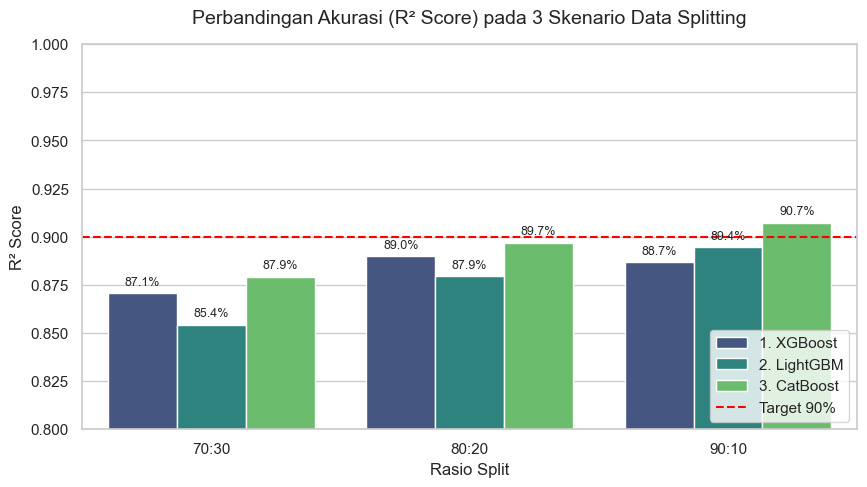


--- METRIK EVALUASI LENGKAP (Khusus Rasio 80:20) ---


,Algoritma,R2 Score,MAE,MSE,RMSE
3,1. XGBoost,0.8900,0.1479,0.0360,0.1898
4,2. LightGBM,0.8794,0.1544,0.0395,0.1987
5,3. CatBoost,0.8969,0.1443,0.0338,0.1837


In [8]:
# ==========================================
# CELL 8: VISUALISASI & TABEL PERBANDINGAN
# ==========================================
pd.reset_option('display.float_format')

df_lengkap = pd.DataFrame(hasil_eksperimen_lengkap)

# Mengubah format desimal menjadi 4 angka di belakang koma (Hanya untuk tabel Pivot ini)
tabel_pivot_r2 = df_lengkap.pivot(index="Algoritma", columns="Rasio Split", values="R2 Score")
tabel_pivot_r2 = tabel_pivot_r2.map(lambda x: f"{x:.4f}")

print("--- TABEL PERBANDINGAN AKURASI (TARGET ≥ 90%) ---")
display(tabel_pivot_r2)

# Membuat visualisasi grafik batang
plt.figure(figsize=(10, 5))
sns.barplot(x="Rasio Split", y="R2 Score", hue="Algoritma", data=df_lengkap, palette="viridis")
plt.title("Perbandingan Akurasi (R² Score) pada 3 Skenario Data Splitting", fontsize=14, pad=15)
plt.axhline(y=0.90, color='red', linestyle='--', label='Target 90%')
plt.ylim(0.80, 1.0)
plt.ylabel("R² Score")
plt.legend(loc='lower right')

# Menambahkan teks angka di atas batang
for p in plt.gca().patches:
    plt.gca().annotate(f"{p.get_height()*100:.1f}%", 
                       (p.get_x() + p.get_width() / 2., p.get_height()), 
                       ha='center', va='center', xytext=(0, 8), textcoords='offset points', fontsize=9)
plt.show()

print("\n--- METRIK EVALUASI LENGKAP (Khusus Rasio 80:20) ---")
# Format angka metrik menjadi lebih rapi
tabel_evaluasi = df_lengkap[df_lengkap['Rasio Split'] == '80:20'].copy()
for col in ['R2 Score', 'MAE', 'MSE', 'RMSE']:
    tabel_evaluasi[col] = tabel_evaluasi[col].apply(lambda x: f"{x:.4f}")

display(tabel_evaluasi[['Algoritma', 'R2 Score', 'MAE', 'MSE', 'RMSE']])

--- TABEL PERBANDINGAN AKURASI (TARGET ≥ 90%) ---


Rasio Split,70:30,80:20,90:10
Algoritma,,,
1. XGBoost,0.8708,0.8900,0.8866
2. LightGBM,0.8542,0.8794,0.8945
3. CatBoost,0.8793,0.8969,0.9073


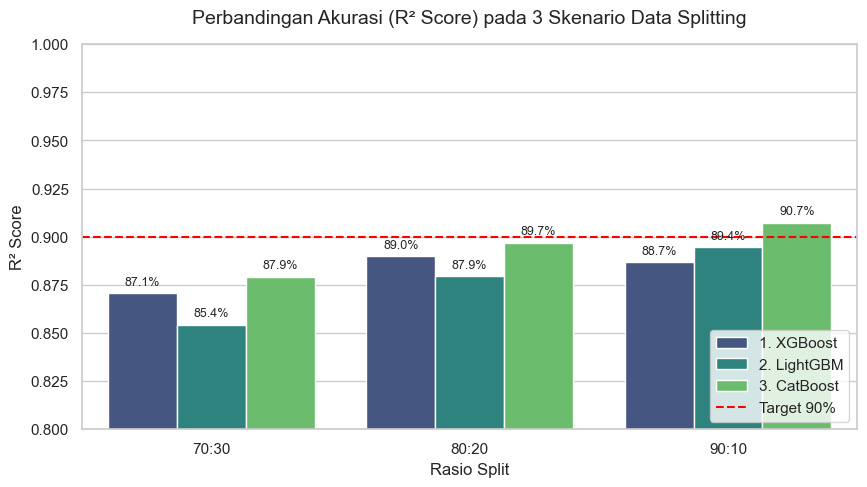


--- METRIK EVALUASI LENGKAP (Khusus Rasio 80:20) ---


,Algoritma,R2 Score,MAE,MSE,RMSE
3,1. XGBoost,0.8900,0.1479,0.0360,0.1898
4,2. LightGBM,0.8794,0.1544,0.0395,0.1987
5,3. CatBoost,0.8969,0.1443,0.0338,0.1837


In [9]:
# ==========================================
# CELL 8: VISUALISASI & TABEL PERBANDINGAN
# ==========================================
pd.reset_option('display.float_format')

df_lengkap = pd.DataFrame(hasil_eksperimen_lengkap)

# Mengubah format desimal menjadi 4 angka di belakang koma (Hanya untuk tabel Pivot ini)
tabel_pivot_r2 = df_lengkap.pivot(index="Algoritma", columns="Rasio Split", values="R2 Score")
tabel_pivot_r2 = tabel_pivot_r2.map(lambda x: f"{x:.4f}")

print("--- TABEL PERBANDINGAN AKURASI (TARGET ≥ 90%) ---")
display(tabel_pivot_r2)

# Membuat visualisasi grafik batang
plt.figure(figsize=(10, 5))
sns.barplot(x="Rasio Split", y="R2 Score", hue="Algoritma", data=df_lengkap, palette="viridis")
plt.title("Perbandingan Akurasi (R² Score) pada 3 Skenario Data Splitting", fontsize=14, pad=15)
plt.axhline(y=0.90, color='red', linestyle='--', label='Target 90%')
plt.ylim(0.80, 1.0)
plt.ylabel("R² Score")
plt.legend(loc='lower right')

# Menambahkan teks angka di atas batang
for p in plt.gca().patches:
    plt.gca().annotate(f"{p.get_height()*100:.1f}%", 
                       (p.get_x() + p.get_width() / 2., p.get_height()), 
                       ha='center', va='center', xytext=(0, 8), textcoords='offset points', fontsize=9)
plt.show()

print("\n--- METRIK EVALUASI LENGKAP (Khusus Rasio 80:20) ---")
# Format angka metrik menjadi lebih rapi
tabel_evaluasi = df_lengkap[df_lengkap['Rasio Split'] == '80:20'].copy()
for col in ['R2 Score', 'MAE', 'MSE', 'RMSE']:
    tabel_evaluasi[col] = tabel_evaluasi[col].apply(lambda x: f"{x:.4f}")

display(tabel_evaluasi[['Algoritma', 'R2 Score', 'MAE', 'MSE', 'RMSE']])